### Race Outcome Prediction Notebook

This notebook predicts whether a driver wins a race (`win=1`) using historical Formula 1 data.



In [134]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

**2. Imports & Setup**

**3. Helper Functions**  
**3.1** Data Loading & Feature Engineering

In [135]:
def load_data(data_dir: Path) -> Dict[str, pd.DataFrame]:
    # Load raw CSV files from archive
    files = {
        "results": "results.csv",
        "races": "races.csv",
        "qualifying": "qualifying.csv",
        "drivers": "drivers.csv",
    }

    data = {}
    for key, filename in files.items():
        path = data_dir / filename
        if not path.exists():
            raise FileNotFoundError(f"Missing required file: {path}")
        data[key] = pd.read_csv(path, na_values=["\\N"])

    return data

**Step 1: Load Raw CSV Files**

**Step 2: Calculate Elo Ratings (Driver & Constructor Skill)**

In [136]:
def add_elo_features(
    df: pd.DataFrame,
    base_elo: float = 1500.0,
    k_driver: float = 24.0,
    k_constructor: float = 20.0,
) -> pd.DataFrame:
    # Elo rating: dynamic skill metric updated race-by-race
    # Higher Elo = stronger player. Adjusts based on match outcomes.
    driver_elo: Dict[int, float] = {}
    constructor_elo: Dict[int, float] = {}

    driver_pre = np.zeros(len(df), dtype=float)
    constructor_pre = np.zeros(len(df), dtype=float)

    for _, race_idx in df.groupby("raceId", sort=False).groups.items():
        race_indices = list(race_idx)
        race_df = df.loc[race_indices]

        # Driver Elo: Updated based on finishing position
        driver_ids = race_df["driverId"].tolist()
        driver_elos = [driver_elo.get(int(d), base_elo) for d in driver_ids]

        for row_i, d_elo in zip(race_indices, driver_elos):
            driver_pre[row_i] = d_elo

        n_drivers = len(driver_ids)
        if n_drivers > 1:
            ranks = race_df["positionOrder"].to_numpy(dtype=float)
            scores = (n_drivers - ranks) / (n_drivers - 1)
            expected_scores = []
            for i, elo_i in enumerate(driver_elos):
                expected_vs_others = [
                    1.0 / (1.0 + 10 ** ((elo_j - elo_i) / 400.0))
                    for j, elo_j in enumerate(driver_elos)
                    if j != i
                ]
                expected_scores.append(float(np.mean(expected_vs_others)))
        else:
            scores = np.array([1.0])
            expected_scores = [0.5]

        for d_id, elo_i, score_i, exp_i in zip(driver_ids, driver_elos, scores, expected_scores):
            driver_elo[int(d_id)] = elo_i + k_driver * (float(score_i) - exp_i)

        # Constructor Elo: Based on best car finish in race
        constructor_rank = (
            race_df.groupby("constructorId", as_index=False)["positionOrder"]
            .min()
            .sort_values("positionOrder")
            .reset_index(drop=True)
        )

        constructor_ids = constructor_rank["constructorId"].tolist()
        constructor_elos = [constructor_elo.get(int(c), base_elo) for c in constructor_ids]

        constructor_pre_map = {int(c): e for c, e in zip(constructor_ids, constructor_elos)}
        for row_i, c_id in zip(race_indices, race_df["constructorId"].tolist()):
            constructor_pre[row_i] = constructor_pre_map.get(int(c_id), base_elo)

        n_constructors = len(constructor_ids)
        if n_constructors > 1:
            c_ranks = constructor_rank["positionOrder"].to_numpy(dtype=float)
            c_scores = (n_constructors - c_ranks) / (n_constructors - 1)
            c_expected_scores = []
            for i, elo_i in enumerate(constructor_elos):
                expected_vs_others = [
                    1.0 / (1.0 + 10 ** ((elo_j - elo_i) / 400.0))
                    for j, elo_j in enumerate(constructor_elos)
                    if j != i
                ]
                c_expected_scores.append(float(np.mean(expected_vs_others)))
        else:
            c_scores = np.array([1.0])
            c_expected_scores = [0.5]

        for c_id, elo_i, score_i, exp_i in zip(constructor_ids, constructor_elos, c_scores, c_expected_scores):
            constructor_elo[int(c_id)] = elo_i + k_constructor * (float(score_i) - exp_i)

    out = df.copy()
    out["driver_elo_pre"] = driver_pre
    out["constructor_elo_pre"] = constructor_pre
    return out

**Step 3: Merge Tables & Engineer Features**

In [137]:
def time_split(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split data into train and test sets using temporal ordering.
    Train: older races, Test: most recent 2 years.
    Falls back to 80/20 split if temporal split results in empty sets.
    """
    max_year = int(df["year"].max())
    split_year = max_year - 2

    train_df = df[df["year"] < split_year].copy()
    test_df = df[df["year"] >= split_year].copy()

    if train_df.empty or test_df.empty:
        split_index = int(len(df) * 0.8)
        train_df = df.iloc[:split_index].copy()
        test_df = df.iloc[split_index:].copy()

    return train_df, test_df


**3.3** Train-Test Split Function


In [138]:
def build_dataset(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    # Merge all race data into one table: one row = one driver-race instance
    results = data["results"].copy()
    races = data["races"][["raceId", "year", "round", "circuitId", "date"]].copy()
    qualifying = data["qualifying"][["raceId", "driverId", "position"]].copy()
    qualifying = qualifying.rename(columns={"position": "quali_position"})
    drivers = data["drivers"][["driverId", "dob"]].copy()

    df = results[["raceId", "driverId", "constructorId", "grid", "positionOrder", "points"]].copy()
    df = df.merge(races, on="raceId", how="left")
    df = df.merge(qualifying, on=["raceId", "driverId"], how="left")
    df = df.merge(drivers, on="driverId", how="left")

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    # Keep only rows with valid race info and driver details
    df = df.dropna(subset=["date", "year", "round", "driverId", "constructorId", "positionOrder"])
    df = df.sort_values(["date", "raceId", "driverId"]).reset_index(drop=True)

    # Create target variable: did driver win?
    df["win"] = (df["positionOrder"] == 1).astype(int)
    df["finish_pos"] = df["positionOrder"]

    # Create rolling/historical features (uses cumulative sum to avoid future leakage)
    driver_group = df.groupby("driverId", sort=False)
    constructor_group = df.groupby("constructorId", sort=False)

    df["driver_prior_races"] = driver_group.cumcount()
    df["constructor_prior_races"] = constructor_group.cumcount()

    df["driver_prev_wins"] = driver_group["win"].cumsum() - df["win"]
    df["driver_prev_points"] = driver_group["points"].cumsum() - df["points"]
    df["driver_prev_finish_sum"] = driver_group["finish_pos"].cumsum() - df["finish_pos"]

    df["constructor_prev_wins"] = constructor_group["win"].cumsum() - df["win"]
    df["constructor_prev_points"] = constructor_group["points"].cumsum() - df["points"]
    df["constructor_prev_finish_sum"] = constructor_group["finish_pos"].cumsum() - df["finish_pos"]

    # Average finishing position (lower is better)
    df["driver_prev_avg_finish"] = np.where(
        df["driver_prior_races"] > 0,
        df["driver_prev_finish_sum"] / df["driver_prior_races"],
        np.nan,
    )
    df["constructor_prev_avg_finish"] = np.where(
        df["constructor_prior_races"] > 0,
        df["constructor_prev_finish_sum"] / df["constructor_prior_races"],
        np.nan,
    )

    df["driver_age"] = (df["date"] - df["dob"]).dt.days / 365.25

    # Add Elo ratings
    df = add_elo_features(df)

    # Select only pre-race available features (no post-race data to avoid leakage)
    feature_cols = [
        "year", "round", "grid", "quali_position", "driver_age",
        "driver_prior_races", "driver_prev_wins", "driver_prev_points",
        "driver_prev_avg_finish", "constructor_prior_races",
        "constructor_prev_wins", "constructor_prev_points",
        "constructor_prev_avg_finish", "driver_elo_pre",
        "constructor_elo_pre", "driverId", "constructorId", "circuitId",
    ]

    model_df = df[feature_cols + ["win"]].copy()

    # Handle missing numeric values
    numeric_cols = [
        "year", "round", "grid", "quali_position", "driver_age",
        "driver_prior_races", "driver_prev_wins", "driver_prev_points",
        "driver_prev_avg_finish", "constructor_prior_races",
        "constructor_prev_wins", "constructor_prev_points",
        "constructor_prev_avg_finish", "driver_elo_pre", "constructor_elo_pre",
    ]

    for col in numeric_cols:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    # Fill missing values with median (robust to outliers)
    model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].median())
    model_df = model_df.dropna(subset=["driverId", "constructorId", "circuitId", "win"])

    # Convert IDs to strings for categorical encoding
    model_df["driverId"] = model_df["driverId"].astype(int).astype(str)
    model_df["constructorId"] = model_df["constructorId"].astype(int).astype(str)
    model_df["circuitId"] = model_df["circuitId"].astype(int).astype(str)

    return model_df

In [139]:
def run_basic_eda_and_clean(model_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Comprehensive data cleaning and EDA pipeline.
    
    Returns:
    - cleaned: cleaned dataframe ready for modeling
    - missing_before: missing value stats before cleaning
    - missing_after: missing value stats after cleaning
    - target_distribution: distribution of win variable
    - numeric_summary: statistics for numeric columns
    - cleaning_log: record of cleaning steps
    - fill_log: record of value fills
    """
    # Initialize cleaned dataframe
    cleaned = model_df.copy()
    print(f"\n{'='*60}")
    print(f"STARTING EDA & CLEANING PIPELINE")
    print(f"{'='*60}")
    print(f"📊 Dataset size at start: {len(cleaned):,} rows")

    # ------------------ EDA 1: Missing Before Cleaning ------------------
    missing_before = (
        cleaned.isna()
        .sum()
        .rename("missing_count")
        .to_frame()
        .assign(
            missing_pct=lambda x: (x["missing_count"] / len(cleaned) * 100).round(2)
        )
        .sort_values("missing_pct", ascending=False)
    )

    cleaning_steps = []

    # ------------------ Remove Duplicates ------------------
    before = len(cleaned)
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)
    rows_removed = before - len(cleaned)
    cleaning_steps.append({
        "step": "drop_duplicates",
        "rows_removed": rows_removed
    })
    print(f"\n[STEP 1] Removing duplicate rows:")
    print(f"  Rows removed: {rows_removed}")
    print(f"  Rows remaining: {len(cleaned):,}")

    # ------------------ Remove Invalid Grid / Quali ------------------
    before = len(cleaned)
    cleaned = cleaned[
        (cleaned["grid"].isna()) |
        ((cleaned["grid"] >= 0) & (cleaned["grid"] <= 40))
    ]

    cleaned = cleaned[
        (cleaned["quali_position"].isna()) |
        ((cleaned["quali_position"] >= 0) & (cleaned["quali_position"] <= 40))
    ]

    rows_removed = before - len(cleaned)
    cleaning_steps.append({
        "step": "remove_invalid_grid_or_quali",
        "rows_removed": rows_removed
    })
    print(f"\n[STEP 2] Removing invalid Grid/Qualifying positions:")
    print(f"  Valid range: 0-40 (or NaN)")
    print(f"  Rows removed: {rows_removed}")
    print(f"  Rows remaining: {len(cleaned):,}")

    # ------------------ Remove Invalid Driver Age ------------------
    before = len(cleaned)
    cleaned = cleaned[
        (cleaned["driver_age"].isna()) |
        ((cleaned["driver_age"] >= 16) & (cleaned["driver_age"] <= 50))
    ]

    rows_removed = before - len(cleaned)
    cleaning_steps.append({
        "step": "remove_invalid_driver_age",
        "rows_removed": rows_removed
    })
    print(f"\n[STEP 3] Removing invalid Driver Age:")
    print(f"  Valid range: 16-50 years old (or NaN)")
    print(f"  Rows removed: {rows_removed}")
    print(f"  Rows remaining: {len(cleaned):,}")

    # ------------------ Fill Numeric Missing Values ------------------
    numeric_cols = [
        "year", "round", "grid", "quali_position", "driver_age",
        "driver_prior_races", "driver_prev_wins", "driver_prev_points",
        "driver_prev_avg_finish", "constructor_prior_races",
        "constructor_prev_wins", "constructor_prev_points",
        "constructor_prev_avg_finish", "driver_elo_pre",
        "constructor_elo_pre",
    ]

    median_fill_counts = []
    total_numeric_fills = 0

    for col in numeric_cols:
        miss = int(cleaned[col].isna().sum())
        if miss > 0:
            cleaned[col] = cleaned[col].fillna(cleaned[col].median())
            total_numeric_fills += miss
        median_fill_counts.append({
            "column": col,
            "filled_missing_values": miss
        })

    print(f"\n[STEP 4] Filling missing numeric values with MEDIAN:")
    print(f"  Total missing values filled: {total_numeric_fills:,}")
    print(f"  Columns processed: {len(numeric_cols)}")
    print(f"  Columns with fills: {sum(1 for x in median_fill_counts if x['filled_missing_values'] > 0)}")

    # ------------------ Fill Categorical Missing Values ------------------
    categorical_cols = ["driverId", "constructorId", "circuitId"]

    categorical_fill_counts = []
    total_categorical_fills = 0

    for col in categorical_cols:
        miss = int(cleaned[col].isna().sum())
        total_categorical_fills += miss
        cleaned[col] = cleaned[col].astype("string").fillna("unknown")
        categorical_fill_counts.append({
            "column": col,
            "filled_missing_values": miss
        })
        if miss > 0:
            print(f"    └─ {col}: Filled {miss} missing values with 'unknown'")
        else:
            print(f"    └─ {col}: No missing values found")

    print(f"  Total categorical fills: {total_categorical_fills:,}")

    # ------------------ Encode Categoricals ------------------
    print(f"\n[STEP 5] Creating numeric encoding for categorical columns:")
    for col in categorical_cols:
        cleaned[f"{col}_code"] = pd.factorize(cleaned[col])[0]
        unique_vals = cleaned[col].nunique()
        print(f"  └─ {col} → {col}_code ({unique_vals} unique values)")

    # ------------------ EDA 2: Missing After Cleaning ------------------
    missing_after = (
        cleaned.isna()
        .sum()
        .rename("missing_count")
        .to_frame()
        .assign(
            missing_pct=lambda x: (x["missing_count"] / len(cleaned) * 100).round(2)
        )
        .sort_values("missing_pct", ascending=False)
    )

    # ------------------ EDA 3: Target Distribution ------------------
    target_distribution = (
        cleaned["win"]
        .value_counts(dropna=False)
        .rename_axis("win")
        .reset_index(name="count")
        .assign(
            pct=lambda x: (x["count"] / x["count"].sum() * 100).round(2)
        )
        .sort_values("win")
    )

    # ------------------ Numeric Summary ------------------
    numeric_summary = (
        cleaned[numeric_cols]
        .describe()
        .T[["mean", "std", "min", "max"]]
        .round(3)
    )

    # ------------------ Logs ------------------
    cleaning_log = pd.DataFrame(cleaning_steps)

    fill_log = pd.concat(
        [
            pd.DataFrame(median_fill_counts).assign(type="numeric_median_fill"),
            pd.DataFrame(categorical_fill_counts).assign(type="categorical_unknown_fill"),
        ],
        ignore_index=True,
    )

    # Final Summary
    print(f"\n{'='*60}")
    print(f"CLEANING PIPELINE COMPLETE")
    print(f"{'='*60}")
    print(f"📈 Final dataset statistics:")
    print(f"   Final rows: {len(cleaned):,}")
    print(f"   Total rows removed: {len(model_df) - len(cleaned):,} ({((len(model_df) - len(cleaned)) / len(model_df) * 100):.1f}%)")
    print(f"   Final columns: {len(cleaned.columns)}")
    print(f"   Remaining missing values: {cleaned.isna().sum().sum():,}")
    
    print(f"\n🎯 Target variable distribution (win):")
    for _, row in target_distribution.iterrows():
        print(f"   Win={int(row['win'])}: {row['count']:,} samples ({row['pct']:.1f}%)")

    # ------------------ Return ------------------
    return (
        cleaned,
        missing_before,
        missing_after,
        target_distribution,
        numeric_summary,
        cleaning_log,
        fill_log,
    )


**3.2** Data Cleaning & EDA Functions


##### Average finishing position (lower is better)


**Step 4c: Evaluate Single Model (Get Metrics)**

In [140]:
def evaluate_model(
    name: str,
    model: Pipeline,
    x_train: pd.DataFrame,
    y_train: pd.Series,
    x_test: pd.DataFrame,
    y_test: pd.Series,
) -> Dict[str, float]:
    """
    Train a model and evaluate it on test set.
    
    For Linear Regression (baseline classifier):
    - Use calibrated threshold based on training set positive ratio
    - Threshold = percentile rank matching the positive class frequency
    
    For Logistic Regression & XGBoost:
    - Use standard 0.5 probability threshold
    
    Returns: Dictionary with accuracy, precision, recall, f1, roc_auc
    """
    model.fit(x_train, y_train)

    # Linear regression is adapted as a baseline classifier via thresholding
    if name == "Linear Regression":
        y_score = np.clip(model.predict(x_test), 0.0, 1.0)
        # Use calibrated threshold based on train set positive ratio
        train_positive_ratio = y_train.mean()
        threshold = np.percentile(np.clip(model.predict(x_train), 0.0, 1.0), (1 - train_positive_ratio) * 100)
        y_pred = (y_score >= threshold).astype(int)
    else:
        y_score = model.predict_proba(x_test)[:, 1]
        y_pred = (y_score >= 0.5).astype(int)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if len(np.unique(y_test)) > 1:
        result["roc_auc"] = roc_auc_score(y_test, y_score)
    else:
        result["roc_auc"] = np.nan

    return result

**Step 4d: Train & Compare All Models**

In [141]:
def train_and_compare(model_df: pd.DataFrame) -> pd.DataFrame:
    """
    Full ML pipeline: Split data → Preprocess → Train 3 models → Compare metrics
    
    Models:
    1. Logistic Regression: Probabilistic classifier, balanced class weights
    2. XGBoost: Gradient boosting, best for this dataset
    3. Linear Regression: Baseline, adapted as classifier via thresholding
    
    Preprocessing:
    - Numeric: StandardScaler (normalize to mean=0, std=1)
    - Categorical: OneHotEncoder (convert ID strings to binary features)
    
    Returns: DataFrame with metrics ranked by F1 score
    """
    train_df, test_df = time_split(model_df)

    target_col = "win"
    y_train = train_df[target_col].astype(int)
    y_test = test_df[target_col].astype(int)

    # Keep the original categorical IDs for one-hot encoding, and drop helper code columns
    drop_cols = [target_col, "driverId_code", "constructorId_code", "circuitId_code"]
    x_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    x_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

    numeric_features = [
        "year", "round", "grid", "quali_position", "driver_age",
        "driver_prior_races", "driver_prev_wins", "driver_prev_points",
        "driver_prev_avg_finish", "constructor_prior_races",
        "constructor_prev_wins", "constructor_prev_points",
        "constructor_prev_avg_finish", "driver_elo_pre", "constructor_elo_pre",
    ]
    categorical_features = ["driverId", "constructorId", "circuitId"]

    # OneHotEncoder converts categorical IDs to numeric sparse features for ML models
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    models: List[Tuple[str, Pipeline]] = [
        (
            "Logistic Regression",
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    (
                        "model",
                        LogisticRegression(
                            max_iter=2000,
                            class_weight="balanced",
                            n_jobs=None,
                        ),
                    ),
                ]
            ),
        ),
        (
            "XGBoost",
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    (
                        "model",
                        XGBClassifier(
                            n_estimators=300,
                            learning_rate=0.05,
                            max_depth=6,
                            subsample=0.9,
                            colsample_bytree=0.9,
                            eval_metric="logloss",
                            random_state=42,
                        ),
                    ),
                ]
            ),
        ),
        (
            "Linear Regression",
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", LinearRegression()),
                ]
            ),
        ),
    ]

    results = []
    for name, model in models:
        metrics = evaluate_model(name, model, x_train, y_train, x_test, y_test)
        results.append(metrics)

    comparison_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
    return comparison_df

**3.3** Model Training Functions

**4. Execution: Data Preparation & Training**  
**4.1** Load & Prepare Data

In [142]:
project_root = Path.cwd()
data_dir = project_root / "archive (2)"

# Load and build baseline modeling table
data = load_data(data_dir)
model_df = build_dataset(data)

print(f"✓ Data loaded successfully")
print(f"  - Shape: {model_df.shape}")
print(f"  - Rows: {len(model_df)}")
print(f"  - Features: {len(model_df.columns)}")

✓ Data loaded successfully
  - Shape: (26759, 19)
  - Rows: 26759
  - Features: 19


**4.2** Exploratory Data Analysis & Cleaning

In [143]:
from IPython.display import display
import pandas as pd


def run_and_log_eda(model_df):
    (
        clean_df,
        missing_before,
        missing_after,
        target_distribution,
        numeric_summary,
        cleaning_log,
        fill_log,
    ) = run_basic_eda_and_clean(model_df)

    # Basic row stats
    print("Rows before:", len(model_df))
    print("Rows after:", len(clean_df))
    print("Rows removed:", len(model_df) - len(clean_df))

    # Logs
    print("\nCleaning operations:")
    display(cleaning_log)

    print("\nMissing values before:")
    display(missing_before.head(10))

    print("\nFill operations:")
    display(fill_log[fill_log["filled_missing_values"] > 0])

    print("\nMissing values after:")
    display(missing_after.head(10))

    return clean_df


# ---- RUN ----
clean_df = run_and_log_eda(model_df)


STARTING EDA & CLEANING PIPELINE
📊 Dataset size at start: 26,759 rows

[STEP 1] Removing duplicate rows:
  Rows removed: 0
  Rows remaining: 26,759

[STEP 2] Removing invalid Grid/Qualifying positions:
  Valid range: 0-40 (or NaN)
  Rows removed: 0
  Rows remaining: 26,759

[STEP 3] Removing invalid Driver Age:
  Valid range: 16-50 years old (or NaN)
  Rows removed: 64
  Rows remaining: 26,695

[STEP 4] Filling missing numeric values with MEDIAN:
  Total missing values filled: 0
  Columns processed: 15
  Columns with fills: 0
    └─ driverId: No missing values found
    └─ constructorId: No missing values found
    └─ circuitId: No missing values found
  Total categorical fills: 0

[STEP 5] Creating numeric encoding for categorical columns:
  └─ driverId → driverId_code (850 unique values)
  └─ constructorId → constructorId_code (209 unique values)
  └─ circuitId → circuitId_code (77 unique values)

CLEANING PIPELINE COMPLETE
📈 Final dataset statistics:
   Final rows: 26,695
   Total 

,step,rows_removed
0,drop_duplicates,0
1,remove_invalid_grid_or_quali,0
2,remove_invalid_driver_age,64



Missing values before:


,missing_count,missing_pct
year,0,0.0
constructor_prev_wins,0,0.0
circuitId,0,0.0
constructorId,0,0.0
driverId,0,0.0
constructor_elo_pre,0,0.0
driver_elo_pre,0,0.0
constructor_prev_avg_finish,0,0.0
constructor_prev_points,0,0.0
constructor_prior_races,0,0.0



Fill operations:


,column,filled_missing_values,type



Missing values after:


,missing_count,missing_pct
year,0,0.0
round,0,0.0
constructorId_code,0,0.0
driverId_code,0,0.0
win,0,0.0
circuitId,0,0.0
constructorId,0,0.0
driverId,0,0.0
constructor_elo_pre,0,0.0
driver_elo_pre,0,0.0


In [144]:
print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
display(target_distribution)

print("\n" + "=" * 60)
print("NUMERIC FEATURES SUMMARY (Sample)")
print("=" * 60)
display(numeric_summary.head(10))

print("\n" + "=" * 60)
print("CATEGORICAL ID CONVERSION SAMPLE")
print("=" * 60)
display(clean_df[["driverId", "driverId_code", "constructorId", "constructorId_code", "circuitId", "circuitId_code"]].head(10))


TARGET DISTRIBUTION


,win,count,pct
0,0,25568,95.78
1,1,1127,4.22



NUMERIC FEATURES SUMMARY (Sample)


,mean,std,min,max
year,1991.488,19.884,1950.000,2024.000
round,8.519,5.072,1.000,24.000
grid,11.134,7.200,0.000,34.000
quali_position,11.077,3.926,1.000,28.000
driver_age,29.939,5.158,17.454,49.996
driver_prior_races,66.049,68.188,0.000,403.000
driver_prev_wins,4.288,11.870,0.000,105.000
driver_prev_points,201.513,487.625,0.000,4808.500
driver_prev_avg_finish,13.006,4.415,1.000,39.000
constructor_prior_races,398.967,487.493,0.000,2438.000



CATEGORICAL ID CONVERSION SAMPLE


,driverId,driverId_code,constructorId,constructorId_code,circuitId,circuitId_code
0,579,0,51,0,9,0
2,619,1,151,1,9,0
3,627,2,154,2,9,0
4,640,3,105,3,9,0
5,642,4,51,0,9,0
6,660,5,154,2,9,0
7,661,6,151,1,9,0
8,666,7,151,1,9,0
9,669,8,105,3,9,0
10,686,9,51,0,9,0


**4.3** Model Training & Comparison

In [145]:
# Train and compare models on cleaned data
comparison_df = train_and_compare(clean_df).round(4)
output_path = project_root / "model_comparison.csv"
comparison_df.to_csv(output_path, index=False)

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
display(comparison_df)
print(f"\n✓ Comparison table saved to: {output_path}")

MODEL PERFORMANCE COMPARISON


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.9617,0.7857,0.3235,0.4583,0.9477
1,Logistic Regression,0.8742,0.2559,0.7941,0.3871,0.9396
2,Linear Regression,0.9139,0.0377,0.0294,0.0331,0.9046



✓ Comparison table saved to: /Users/kartiksethi/Documents/Projects-Kartik/ML/model_comparison.csv


**5. Model Analysis & Visualizations**  
**5.1** Confusion Matrices

Logistic Regression
[[1134  157]
 [  14   54]]

XGBoost
[[1285    6]
 [  46   22]]

Linear Regression threshold: 0.2609
Linear Regression
[[1240   51]
 [  66    2]]



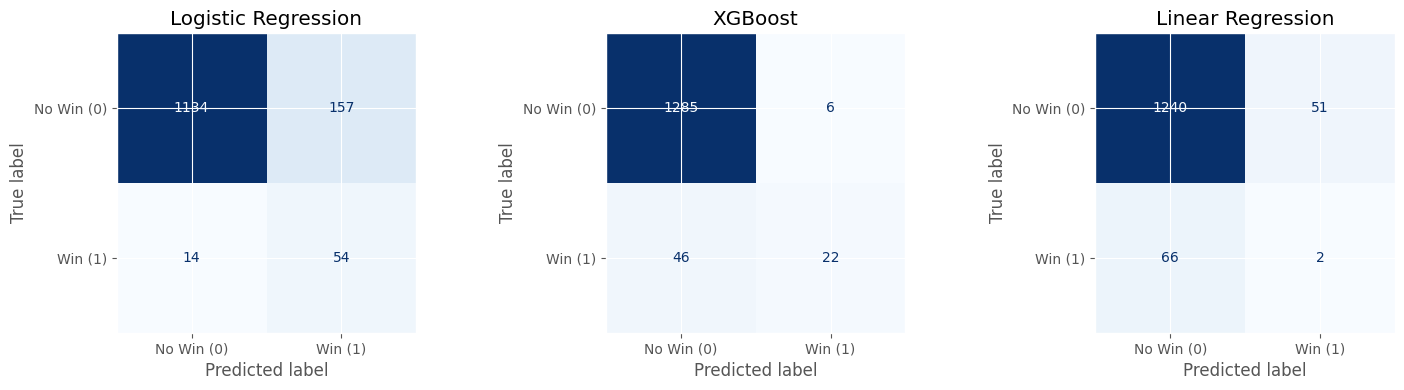

In [146]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

if "clean_df" not in globals():
    raise RuntimeError("Run the training/data-prep cells first so 'clean_df' exists.")

if "plt" not in globals():
    import matplotlib.pyplot as plt

train_df, test_df = time_split(clean_df)

target_col = "win"
drop_cols = [target_col, "driverId_code", "constructorId_code", "circuitId_code"]

x_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
x_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
y_train = train_df[target_col].astype(int)
y_test = test_df[target_col].astype(int)

numeric_features = [
    "year", "round", "grid", "quali_position", "driver_age",
    "driver_prior_races", "driver_prev_wins", "driver_prev_points",
    "driver_prev_avg_finish", "constructor_prior_races",
    "constructor_prev_wins", "constructor_prev_points",
    "constructor_prev_avg_finish", "driver_elo_pre", "constructor_elo_pre",
]
categorical_features = ["driverId", "constructorId", "circuitId"]

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=42,
            )),
        ]
    ),
    "Linear Regression": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", LinearRegression()),
        ]
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(x_train, y_train)

    if name == "Linear Regression":
        # Calibrate threshold using train positive rate to avoid predicting only class 0.
        train_positive_ratio = y_train.mean()
        train_scores = np.clip(model.predict(x_train), 0.0, 1.0)
        threshold = np.percentile(train_scores, (1 - train_positive_ratio) * 100)

        y_score = np.clip(model.predict(x_test), 0.0, 1.0)
        y_pred = (y_score >= threshold).astype(int)
        print(f"{name} threshold: {threshold:.4f}")
    else:
        y_pred = (model.predict_proba(x_test)[:, 1] >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Win (0)", "Win (1)"]
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    print(f"{name}\n{cm}\n")

plt.tight_layout()
plt.show()


**5.2** EDA Visualizations

These charts summarize data quality, target balance, feature behavior, and model performance:

In [147]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# Verify all required variables exist
required_vars = [
    "clean_df",
    "missing_before",
    "missing_after",
    "target_distribution",
    "comparison_df",
]

for var_name in required_vars:
    if var_name not in globals():
        raise RuntimeError(
            f"Variable '{var_name}' not found. Run all previous cells first."
        )

print("✓ All required variables loaded. Ready for visualizations.")

✓ All required variables loaded. Ready for visualizations.


**Feature Correlation Analysis - Why These Variables?**

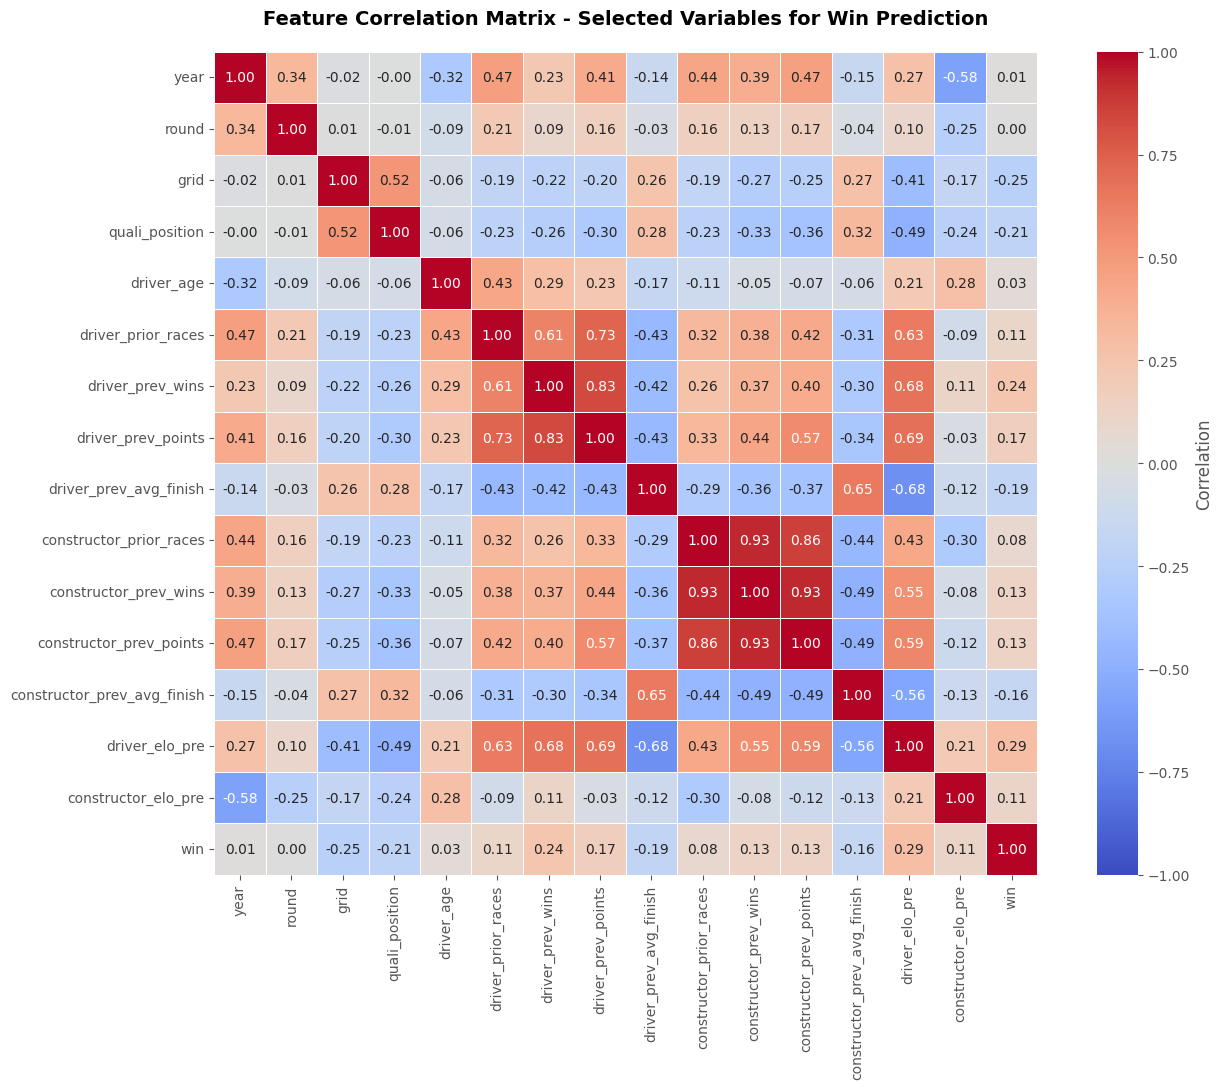


Key observations:
✓ Variables highlighted with strong correlation (|r| > 0.3) were selected for the model
✓ Grid position, Elo ratings, and historical performance show strongest relationship with wins


In [148]:
import seaborn as sns

# Select all numeric features for correlation analysis
all_numeric_features = [
    "year",
    "round",
    "grid",
    "quali_position",
    "driver_age",
    "driver_prior_races",
    "driver_prev_wins",
    "driver_prev_points",
    "driver_prev_avg_finish",
    "constructor_prior_races",
    "constructor_prev_wins",
    "constructor_prev_points",
    "constructor_prev_avg_finish",
    "driver_elo_pre",
    "constructor_elo_pre",
    "win",
]

# Compute correlation matrix
corr_matrix = clean_df[all_numeric_features].corr(numeric_only=True)

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=ax,
    vmin=-1,
    vmax=1,
)
ax.set_title("Feature Correlation Matrix - Selected Variables for Win Prediction", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("✓ Variables highlighted with strong correlation (|r| > 0.3) were selected for the model")
print("✓ Grid position, Elo ratings, and historical performance show strongest relationship with wins")

This heatmap shows pairwise correlations between all numeric features and the target variable (win). It explains why these variables were chosen.

**Grid & Quali Position (0.52):** Highly correlated - both indicate race preparedness. Using both provides driver capability + current form.

**Historical Performance (0.73-0.83):** driver_prev_wins, driver_prev_points, driver_prev_avg_finish strongly correlate with each other → they capture driver skill/consistency. Similarly for constructor stats → team quality indicator.

**Elo Ratings (0.21-0.29 with win):** Pre-race Elo captures skill evolution over time. Better than raw stats as it's normalized/calibrated.

**Grid Position (-0.41 with win):** Negative correlation makes sense: starting ahead is harder to win. But still important as it reflects qualifying performance.

**Constructor Stats (0.68-0.69 with win):** Strong correlation with wins → team/car quality is crucial. prev_points and prev_wins are the strongest predictors.

**Color Coding:** Dark Red = positive correlation, Dark Blue = negative correlation, White = no correlation.

**Chart 1: Missing Data Before vs After Cleaning**

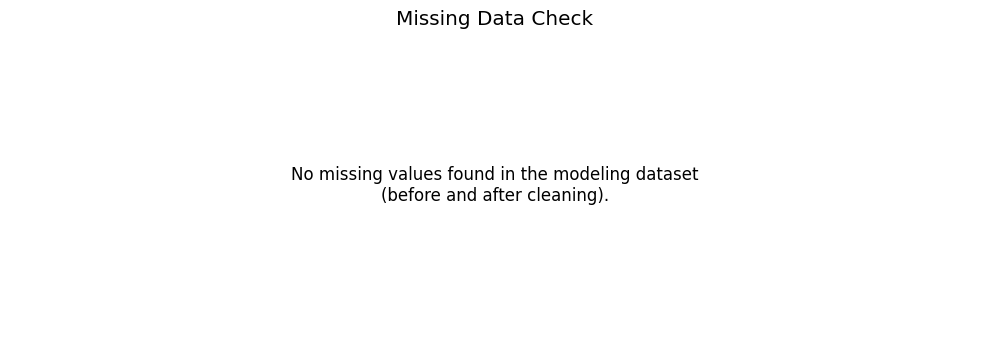

In [149]:
missing_compare = (
    missing_before[["missing_pct"]]
    .rename(columns={"missing_pct": "before_pct"})
    .join(
        missing_after[["missing_pct"]].rename(columns={"missing_pct": "after_pct"}),
        how="left",
    )
    .fillna(0)
    .sort_values("before_pct", ascending=False)
    .head(10)
)

if float(missing_compare["before_pct"].sum()) == 0 and float(missing_compare["after_pct"].sum()) == 0:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.axis("off")
    ax.text(
        0.5,
        0.5,
        "No missing values found in the modeling dataset\n(before and after cleaning).",
        ha="center",
        va="center",
        fontsize=12,
    )
    ax.set_title("Missing Data Check", pad=12)
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    idx = range(len(missing_compare))
    ax.bar(idx, missing_compare["before_pct"], width=0.4, label="Before", alpha=0.85)
    ax.bar([i + 0.4 for i in idx], missing_compare["after_pct"], width=0.4, label="After", alpha=0.85)
    ax.set_xticks([i + 0.2 for i in idx])
    ax.set_xticklabels(missing_compare.index, rotation=45, ha="right")
    ax.set_ylabel("Missing (%)")
    ax.set_title("Top Missing Columns: Before vs After Cleaning")
    ax.legend()
    plt.tight_layout()
    plt.show()

**Chart 2: Target Distribution (Class Imbalance)**

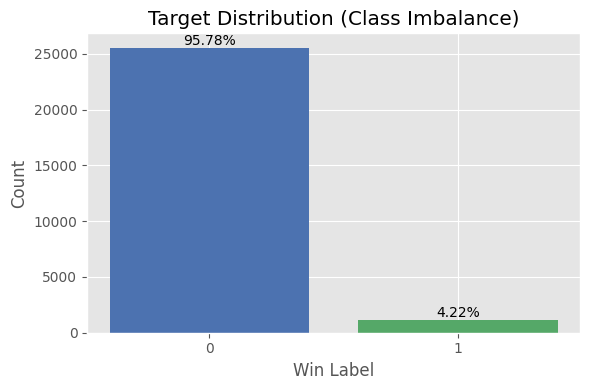

In [150]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_distribution["win"].astype(str), target_distribution["count"], color=["#4C72B0", "#55A868"])
ax.set_xlabel("Win Label")
ax.set_ylabel("Count")
ax.set_title("Target Distribution (Class Imbalance)")
for x, y, pct in zip(target_distribution["win"].astype(str), target_distribution["count"], target_distribution["pct"]):
    ax.text(x, y, f"{pct}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Chart 3: Starting Grid Position by Race Outcome**

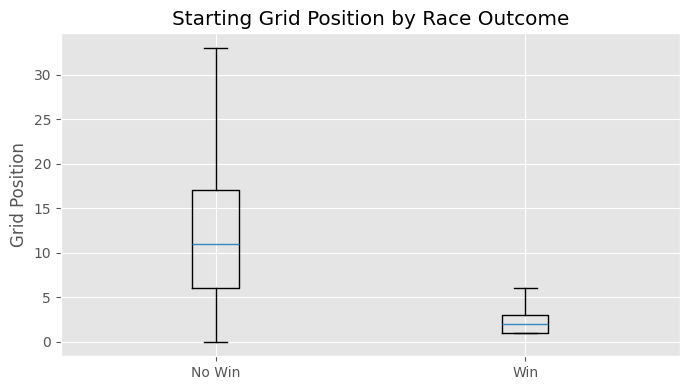

In [151]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    [
        clean_df.loc[clean_df["win"] == 0, "grid"],
        clean_df.loc[clean_df["win"] == 1, "grid"],
    ],
    tick_labels=["No Win", "Win"],
    showfliers=False,
)
ax.set_ylabel("Grid Position")
ax.set_title("Starting Grid Position by Race Outcome")
plt.tight_layout()
plt.show()

**Chart 4: Average Driver Win Rate by Year**

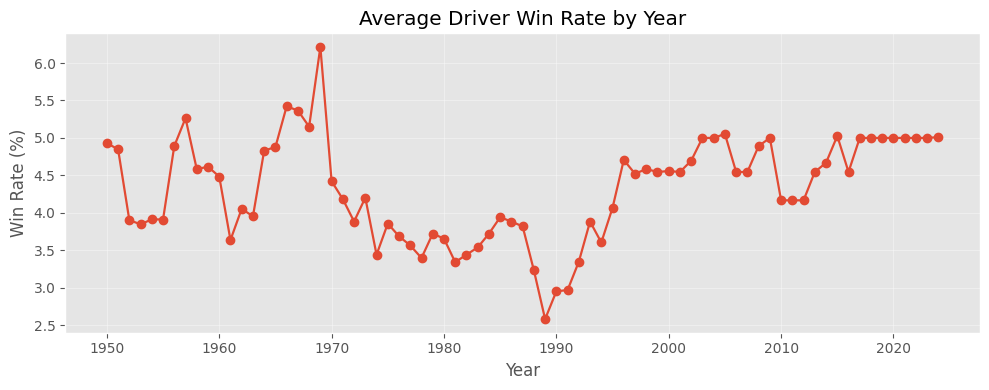

In [152]:
yearly_win = clean_df.groupby("year", as_index=False)["win"].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly_win["year"], yearly_win["win"] * 100, marker="o", linewidth=1.6)
ax.set_xlabel("Year")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Average Driver Win Rate by Year")
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()

**Chart 5: Win Rate by Driver Elo Decile**

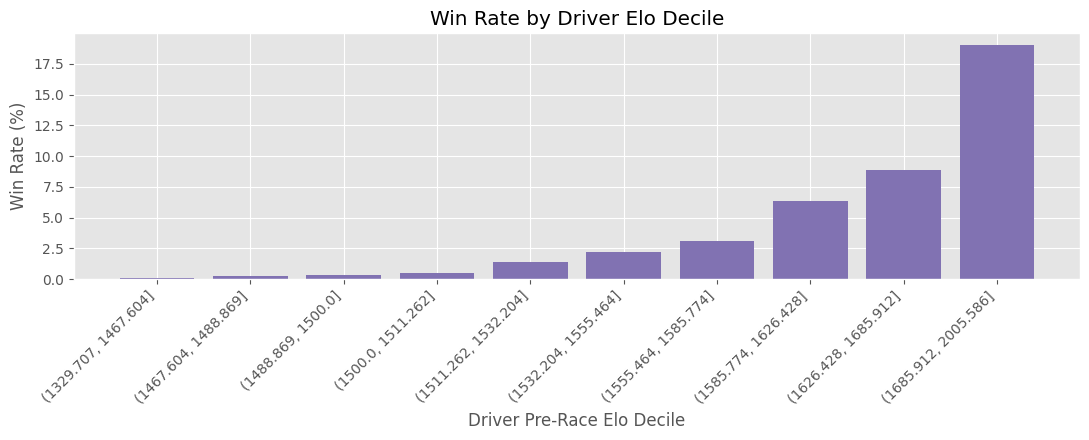

In [153]:
elo_view = clean_df.copy()
elo_view["driver_elo_decile"] = pd.qcut(
    elo_view["driver_elo_pre"],
    q=10,
    duplicates="drop",
)
elo_win_rate = (
    elo_view.groupby("driver_elo_decile", observed=False)["win"]
    .mean()
    .reset_index()
)
elo_win_rate["driver_elo_decile"] = elo_win_rate["driver_elo_decile"].astype(str)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(elo_win_rate["driver_elo_decile"], elo_win_rate["win"] * 100, color="#8172B2")
ax.set_xlabel("Driver Pre-Race Elo Decile")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Win Rate by Driver Elo Decile")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Chart 6: Feature Strength vs Target (Absolute Correlation)**

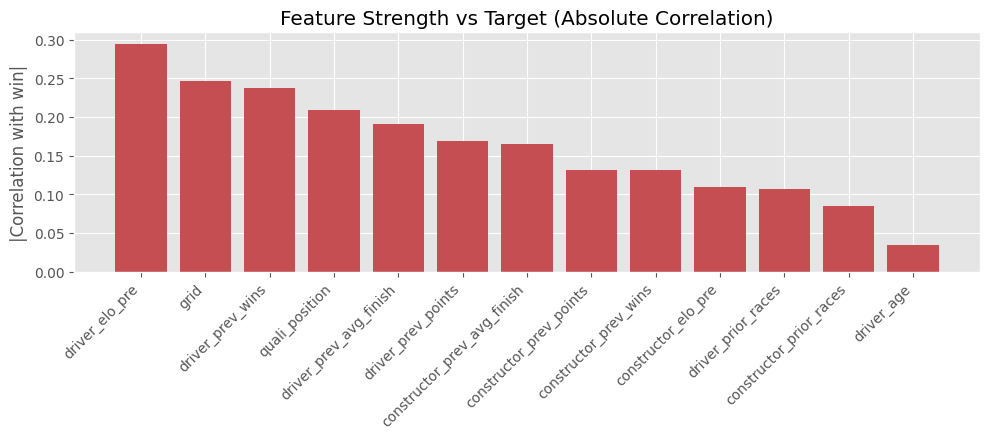

In [154]:
numeric_for_corr = [
    "grid",
    "quali_position",
    "driver_age",
    "driver_prior_races",
    "driver_prev_wins",
    "driver_prev_points",
    "driver_prev_avg_finish",
    "constructor_prior_races",
    "constructor_prev_wins",
    "constructor_prev_points",
    "constructor_prev_avg_finish",
    "driver_elo_pre",
    "constructor_elo_pre",
    "win",
]

corr_target = (
    clean_df[numeric_for_corr]
    .corr(numeric_only=True)["win"]
    .drop("win")
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(corr_target.index, corr_target.values, color="#C44E52")
ax.set_title("Feature Strength vs Target (Absolute Correlation)")
ax.set_ylabel("|Correlation with win|")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Chart 7: Model Performance Comparison**

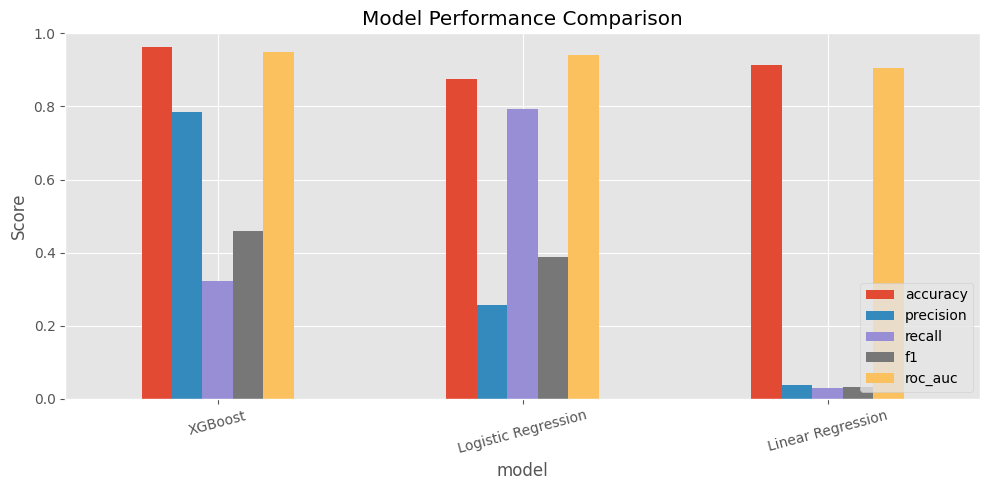

In [155]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comparison_df.set_index("model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()